In [2]:
#!pip install jax
#!pip install lightkurve
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from tqdm import tqdm
from IO import psd

C:\Users\douga\anaconda3\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
#DEFINE SCALING RELATION
    
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772
    
#DEFINE SLIDING AUTOCORRELATION
    
def sliding_acf_search(frequency, #frequency array
                       power_flat, #flattened power spectrum
                       numax_grid, #array of values of nu_max to run autocorrelation around
                       k_width=4.0, #width of each window as a multiple of delta_nu
                       lag_frac=(0.8, 1.2) 
                      ):
    
    acf_strength = []
    df = frequency[1] - frequency[0]
    for nu_c in numax_grid:
    
        #use scaling relation to get estimated delta_nu for each nu_max
        dnu = delta_nu_from_numax(nu_c)
    
        #window width
        W = k_width * dnu

            
        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue
    
        # Local, whitened spectrum
        p = power_flat[mask]
        p = p / np.median(p)
    
        # Autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:]
    
        # Lag axis
        
        lag = np.arange(acf.size) * df
    
        # Measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])
    
        acf_strength.append(strength)
    
    return np.array(acf_strength)

#DEFINE MASK AROUND DELTA_NU_EST PEAK

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac):
        #justify the choices of window_frac = 0.2, mask boundaries
    
        # Central window around delta_nu
        main_lo = delta_nu_est * (1 - window_frac)
        main_hi = delta_nu_est * (1 + window_frac)
    
        mask = (
            (lags > main_lo) & (lags < main_hi)
        )
    
        return lags[mask], acf[mask]

#FUNCTIONS FOR GENERATING NOISE

def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_lvl):
    # freqs: list of frequencies of the data
    # N: number of different fake signals
    # Noise_low/high: lower and upper bounds of the whitenoise level
    signals= []
    for i in tqdm(range(0,N)):
        fake_base=[noise_lvl]*len(freqs)
        fake_signal=random(fake_base)
        signals.append(fake_signal)
    return np.array(signals)

#DEFINE GAUSSIAN

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c

def find_metric(power, freq):
    #SMOOTHING
        
    df = np.median(np.diff(freq))  # µHz
    smooth_width_muHz = 500    #justify smoothing choice - larger scales than delta_nu
    smooth_width_bins = int(smooth_width_muHz / df)
    background = uniform_filter1d(power, size =smooth_width_bins)
    power_flat = power / background
        
    #CALL SLIDING AUTOCORRELATOR, GET NU_MAX_METRIC
        
    numax_grid = np.linspace(50, nu_nyq, 300)   #should run up to nyquist frequency
        
    acf_power = sliding_acf_search(
        freq,
        power_flat,
        numax_grid,
        k_width=4.0
    )
    nu_max_peak = np.max(acf_power)
    baseline1 = np.median(acf_power)
    scatter1 = np.std(acf_power)
    nu_max_metric = (nu_max_peak - baseline1) / scatter1
    
    numax_est = numax_grid[np.argmax(acf_power)]
        
    #RUN AUTOCORRELATION AROUND DELTA_NU_EST
        
    delta_nu_est = delta_nu_from_numax(numax_est)
    width = 4* delta_nu_est
    mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
    freq_window = freq[mask]
    power_window = power_flat[mask]
        
    acf_full = np.correlate(power_window, power_window, mode="full")
    N = len(power_window)
    acf = acf_full[N-1:]
    lags_bins = np.arange(len(acf))
    lags_muHz = lags_bins * df
    acf /= acf[0]
        
    #FIND ACF MAX WITHIN MASK, GIVING DELTA_NU_METRIC
        
    lags_fit, acf_fit = mask_acf_for_deltanu(
        lags_muHz,
        acf,
        delta_nu_est,
        window_frac=0.2
    )
    peak2 = np.max(acf_fit)
    baseline2 = np.median(acf_fit)
    scatter2 = np.std(acf_fit)
    
    delta_nu_metric = (peak2 - baseline2)/scatter2
    
    return nu_max_metric, delta_nu_metric, lags_fit, acf_fit, delta_nu_est, acf_power

def final_fit(lags_fit, acf_fit, delta_nu_est, acf_power):
    if len(acf_fit) < 5 or np.all(acf_fit == acf_fit[0]):
        delta_nu_metric = np.nan
        delta_nu_fit = delta_nu_est
        delta_nu_err = np.nan
    else:
        peak = np.max(acf_fit)
        baseline2 = np.median(acf_fit)
        scatter2 = np.std(acf_fit)
        delta_nu_metric = (peak - baseline2)/scatter2

        # ---- Gaussian fit to Δν ----
        p0 = [peak, delta_nu_est, 0.2*delta_nu_est, baseline2]
        bounds = ([0, 0.5*delta_nu_est, 0.01*delta_nu_est, -np.inf],
                  [np.inf, 1.5*delta_nu_est, 1.0*delta_nu_est, np.inf])
        try:
            popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds, maxfev=5000)
            delta_nu_fit = popt[1]
            delta_nu_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            delta_nu_fit = delta_nu_est
            delta_nu_err = np.nan

    df = np.median(np.diff(freq))

    smooth_env_bins = int(1.5 * delta_nu_fit / df)
    envelope = uniform_filter1d(acf_power, size=smooth_env_bins)
    
    numax_grid = np.linspace(50, nu_nyq, 300)
    numax_est = numax_grid[np.argmax(acf_power)]
    
    mask_env = (numax_grid > numax_est - 5*delta_nu_fit) & (numax_grid < numax_est + 5*delta_nu_fit)
    if np.any(mask_env):
        p0 = [acf_power[mask_env].max(), numax_est, 2*delta_nu_fit, 1]
        try:
            popt, pcov = curve_fit(gaussian, numax_grid[mask_env], acf_power[mask_env], p0=p0, maxfev=5000)
            nu_max_fit = popt[1]
            nu_max_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            nu_max_fit = numax_est
            nu_max_err = np.nan
    else:
        nu_max_fit = numax_est
        nu_max_err = np.nan
            
    return delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err

def find_noise_lvl(power, freq, nu_max_fit, nu_max_err):
    nu_start = nu_max_fit + 3*nu_max_err
    nu_end = freq.max()
    mask = (freq >= nu_start) & (freq <= nu_end)
    noise_lvl = np.median(power[mask]) / np.log(2)
    return noise_lvl

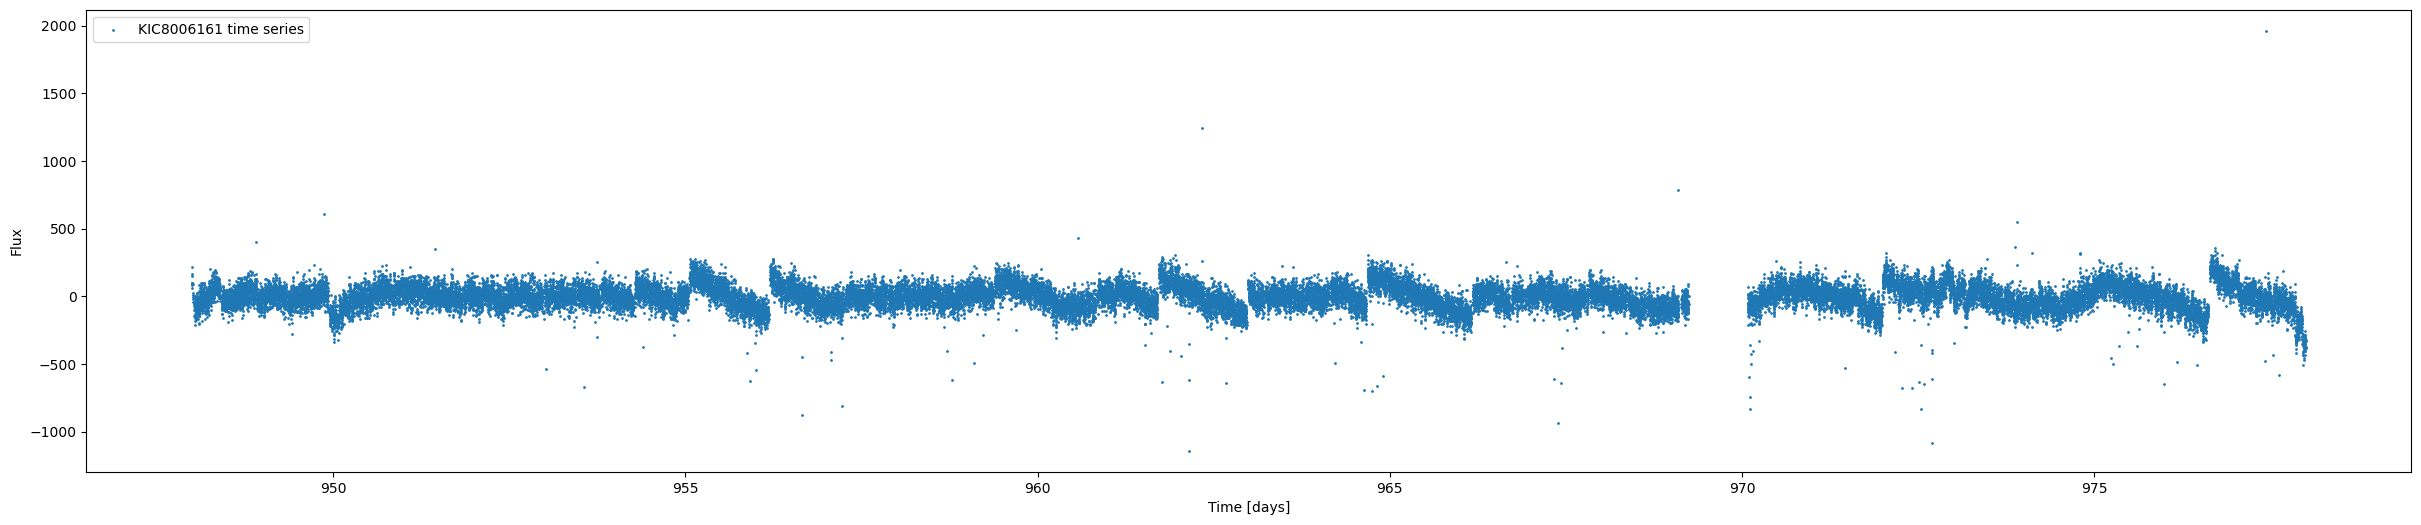

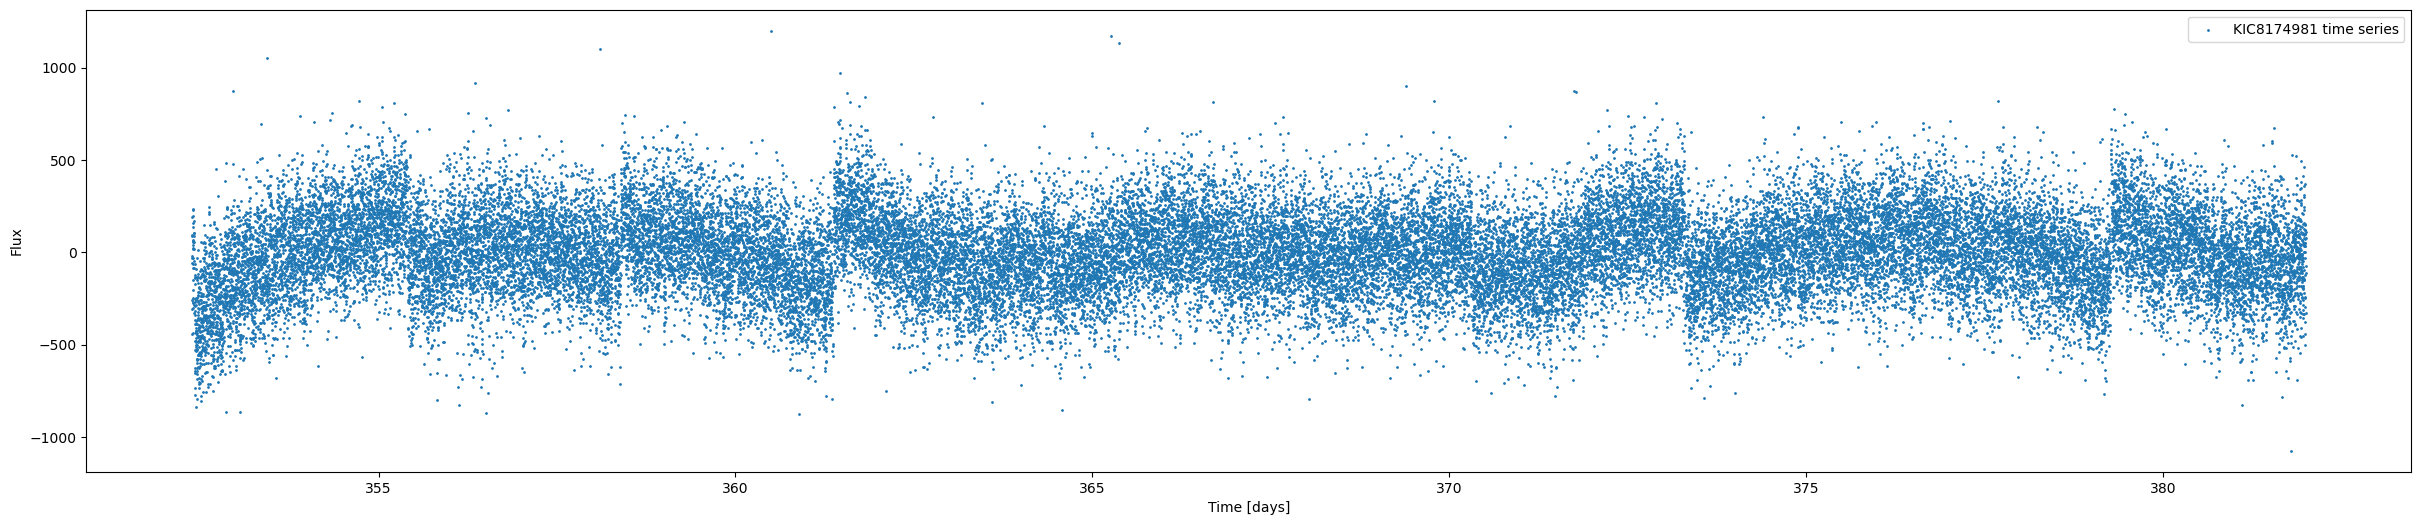

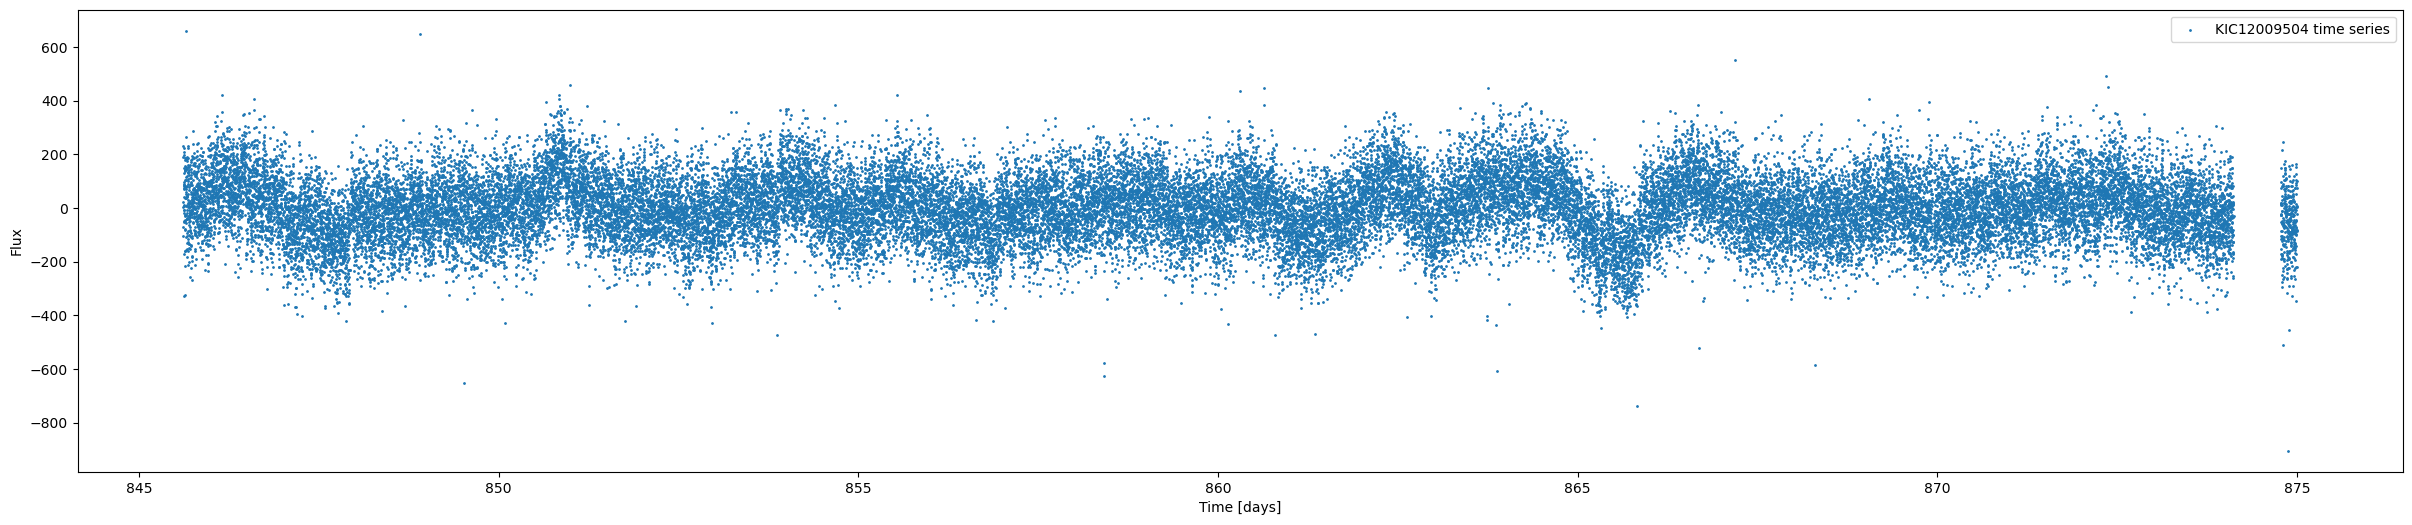

In [5]:
files = ["KIC8006161.dat", "KIC8174981.dat", "KIC12009504.dat"]
time_ranges = [(948, 978), (352, 382), (845, 875)]
labels = ["KIC8006161", "KIC8174981", "KIC12009504"]

times_list = []
fluxes_list = []
lcs_list = []

for f, (t_min, t_max), label in zip(files, time_ranges, labels):
    data = np.loadtxt(f)
    time = data[:, 0]
    flux = data[:, 1]

    mask = (time >= t_min) & (time <= t_max)
    time_sel = time[mask]
    flux_sel = flux[mask]

    times_list.append(time_sel)
    fluxes_list.append(flux_sel)

    fig, ax = plt.subplots(figsize=(30,6))
    lc = lk.LightCurve(time=time_sel, flux=flux_sel)
    lc.scatter(ax=ax, label=f"{label} time series")
    lcs_list.append(lc)
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Flux")
    ax.legend()
    plt.show()

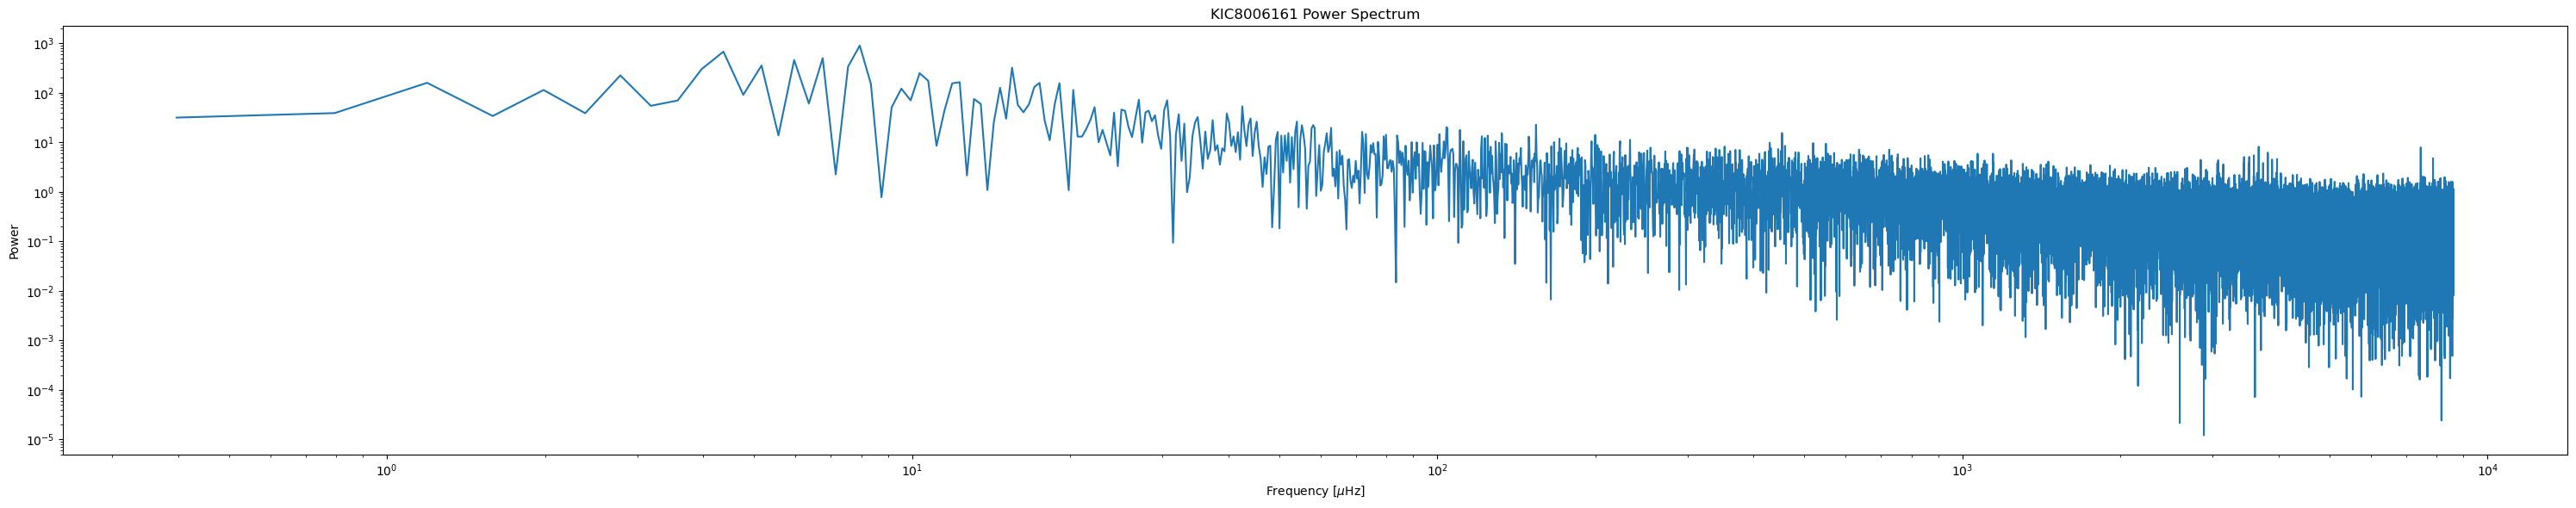

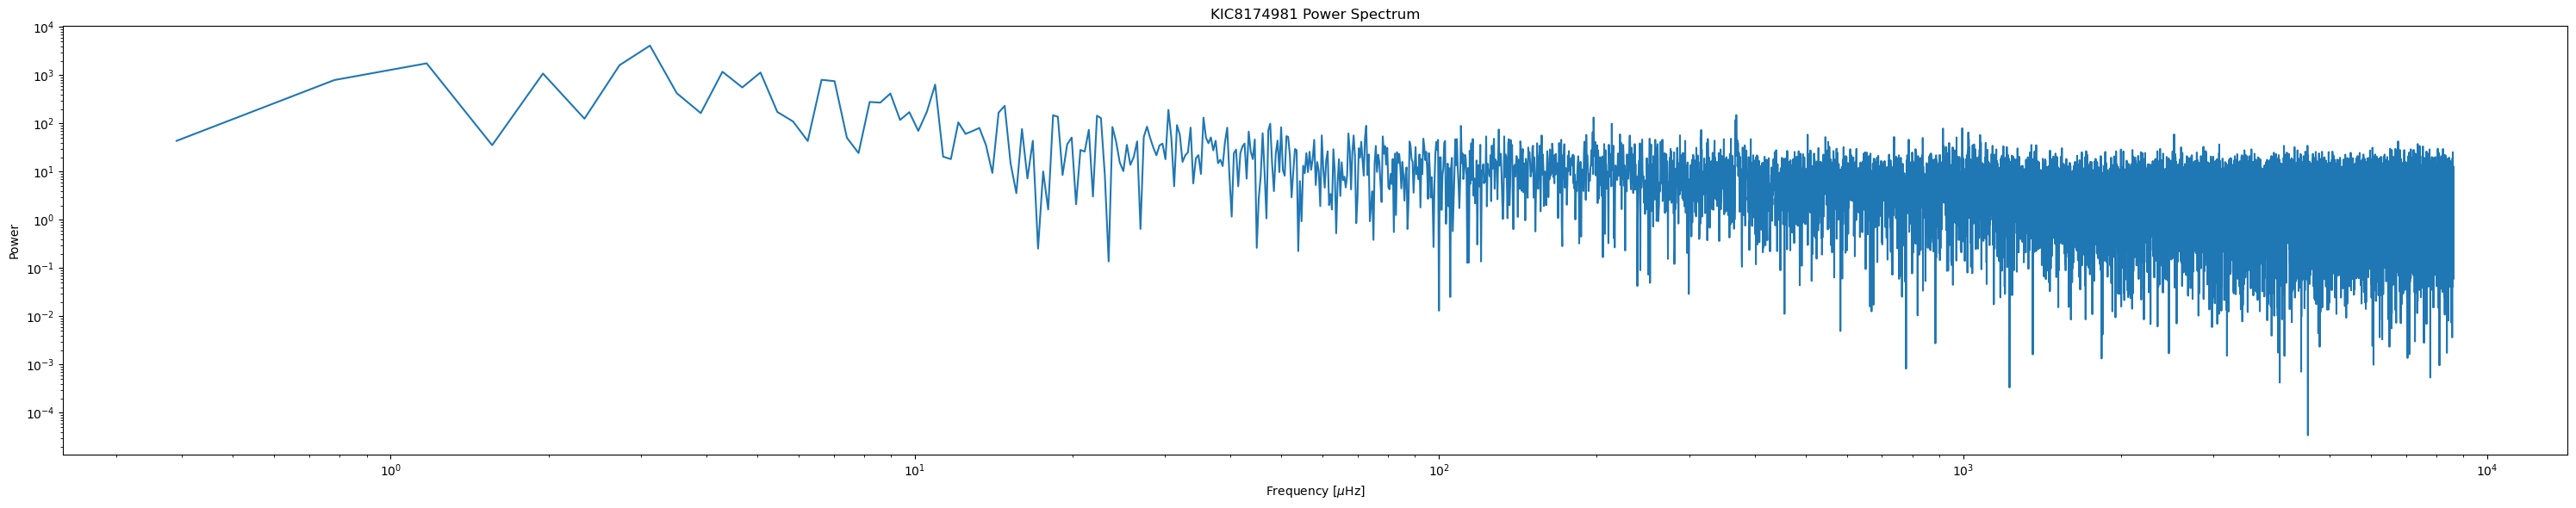

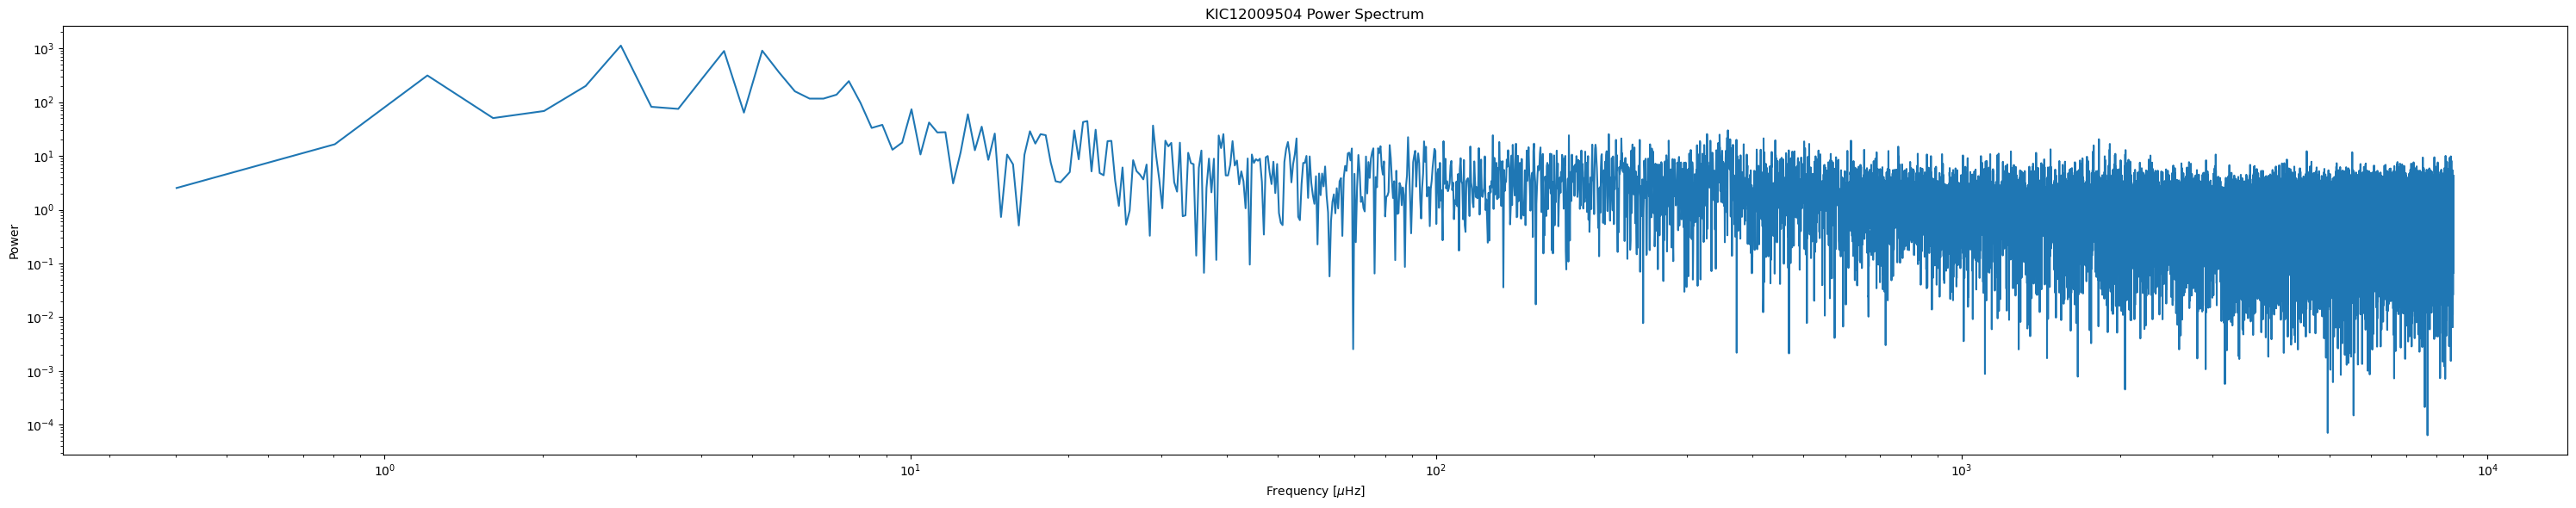

In [6]:
freqs_list = []
powers_list = []

for time_arr, flux_arr, label in zip(times_list, fluxes_list, labels):
    time = np.array(time_arr)
    flux = np.array(flux_arr)

    P = psd(label, time=time, flux=flux)
    P()  # Compute power spectrum

    freq = P.freq  # frequency in μHz
    freqs_list.append(freq)
    power = P.powerdensity  # power density in ppm^2/μHz
    powers_list.append(power)
    
    plt.figure(figsize=(30,6))
    plt.plot(freq, power)
    plt.xlabel("Frequency [$\mu$Hz]")
    plt.ylabel("Power")
    plt.title(f"{label} Power Spectrum")
    plt.yscale("log")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()

In [7]:
# Prepare lists to store results
nu_max_metrics_kepler = []
delta_nu_metrics_kepler = []
combined_metrics_kepler = []

delta_nu_fits = []
delta_nu_errs = []
nu_max_fits = []
nu_max_errs = []

noise_lvls = []
# Loop over all files

for freq, power, label in tqdm(zip(freqs_list, powers_list, labels)):
    nu_nyq = np.max(freq)
    delta_t = (10**6)/(2*nu_nyq)
    
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq)
    
    nu_max_metrics_kepler.append(nu_max)
    delta_nu_metrics_kepler.append(delta_nu)
    combined_metrics_kepler.append(nu_max * delta_nu)

    delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err = final_fit(lags_fit, acf_fit, delta_nu_est, acf_power)
    
    delta_nu_fits.append(delta_nu_fit)
    delta_nu_errs.append(delta_nu_err)
    nu_max_fits.append(nu_max_fit)
    nu_max_errs.append(nu_max_err)

    noise_lvl = find_noise_lvl(power, freq, nu_max_fit, nu_max_err)

    noise_lvls.append(noise_lvl)    

# Convert to NumPy arrays for convenience
nu_max_metrics_kepler = np.array(nu_max_metrics_kepler, dtype=float)
delta_nu_metrics_kepler = np.array(delta_nu_metrics_kepler, dtype=float)
combined_metrics_kepler = np.array(combined_metrics_kepler, dtype=float)
delta_nu_fits = np.array(delta_nu_fits)
delta_nu_errs = np.array(delta_nu_errs)
nu_max_fits = np.array(nu_max_fits)
nu_max_errs = np.array(nu_max_errs)
noise_lvls = np.array(noise_lvls)

print("Nu_max metrics:", nu_max_metrics_kepler)
print("Delta_nu metrics:", delta_nu_metrics_kepler)
print("Combined metrics:", combined_metrics_kepler)
print("Delta_nu:", delta_nu_fits)
print("Delta_nu errors:", delta_nu_errs)
print("Nu_max:", nu_max_fits)
print("Nu_max errors:", nu_max_errs)
print("Noise levels:", noise_lvls)

3it [09:01, 180.60s/it]

Nu_max metrics: [4.14453268 3.74634457 4.41865778]
Delta_nu metrics: [5.6068511  2.9279294  3.04386783]
Combined metrics: [23.23777771 10.96903229 13.44981003]
Delta_nu: [144.49504445  52.89614635  88.94267781]
Delta_nu errors: [1.23123946 0.2834277  0.3048715 ]
Nu_max: [3660.05105081 1021.318851   1891.18151067]
Nu_max errors: [9.43866978 7.70117239 9.32268001]
Noise levels: [0.28824004 4.15597727 1.05240054]


In [8]:
delta_t = 10**(6)/(2*np.max(freqs_list[0]))
print(f"Nyquist frequency: {nu_nyq:.2f}")
print(delta_t)

T = 30*24*60*60 #30 days
#N = int(T/(2*delta_t))
N=len(freqs_list[0])
print(f"Number of data points: {N}")

freq_noise=np.linspace(0,nu_nyq,N)
powers_noise=fake_signals(freq_noise,500,noise_lvl)

Nyquist frequency: 8619.36
58.009945
Number of data points: 21683


100%|██████████| 500/500 [00:56<00:00,  8.90it/s]


In [9]:
nu_max_metrics_noise = []
delta_nu_metrics_noise = []
combined_metrics_noise = []
for power in tqdm(powers_noise):
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)

    nu_max_metrics_noise.append(nu_max)
    delta_nu_metrics_noise.append(delta_nu)
    combined_metrics_noise.append(nu_max * delta_nu)

nu_max_metrics_noise = np.array(nu_max_metrics_noise)
delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
combined_metrics_noise = np.array(combined_metrics_noise)

100%|██████████| 500/500 [03:52<00:00,  2.15it/s]


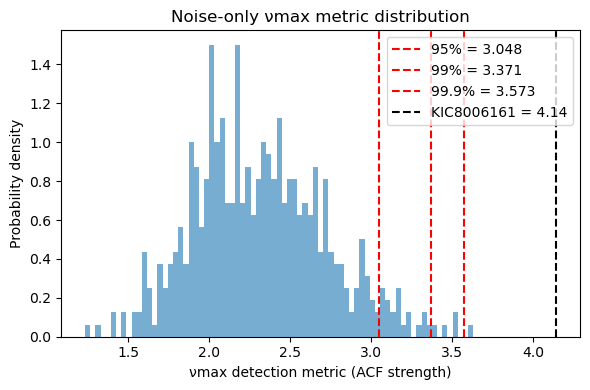

In [10]:
plt.figure(figsize=(6,4))
plt.hist(nu_max_metrics_noise, bins=75, density=True, alpha = 0.6)

for p in [95, 99, 99.9]:
    thr = np.percentile(nu_max_metrics_noise, p)
    plt.axvline(thr, linestyle="--", label=f"{p}% = {thr:.3f}", color = "r")
#for nu_max in nu_max_metrics_kepler:
plt.axvline(nu_max_metrics_kepler[0], linestyle = "--", label = f"{labels[0]} = {nu_max_metrics_kepler[0]:.2f}", color = "k")
plt.xlabel("νmax detection metric (ACF strength)")
plt.ylabel("Probability density")
plt.title("Noise-only νmax metric distribution")
plt.legend()
plt.tight_layout()
plt.savefig("vmax_hist1.png", dpi = 600, bbox_inches = "tight")
plt.show()

In [12]:
def threshold_from_x(x, sig_cad, freq, p):
    nu_nyq = np.max(freq)
    delta_t = 10**(6)/(2*nu_nyq)
    T = 30*24*60*60 #30 days
    N=int(len(freq))
    
    #turn x back into noise_lvl

    sig1hr = (1+x)*sig_cad / np.sqrt(3600/delta_t)
    noise_lvl = (sig1hr**2) * 2 * 3600 * 10**(-6)
    
    freq_noise=np.linspace(0,nu_nyq,N)
    powers_noise=fake_signals(freq_noise,500,noise_lvl)

    nu_max_metrics_noise = []
    #delta_nu_metrics_noise = []
    #combined_metrics_noise = []
    
    for power in tqdm(powers_noise):
        nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)
    
        nu_max_metrics_noise.append(nu_max)
        #delta_nu_metrics_noise.append(delta_nu)
        #combined_metrics_noise.append(nu_max * delta_nu)
    
    nu_max_metrics_noise = np.array(nu_max_metrics_noise)
    #delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
    #combined_metrics_noise = np.array(combined_metrics_noise)

    threshold = np.percentile(nu_max_metrics_noise, p)

    return threshold

def make_spectrum_noisy(x, sig_cad, time, flux, label):
    noise = np.random.normal(0,x*sig_cad, size = len(time))
    flux_noisy = flux + noise
    
    P = psd(label, time=time, flux=flux_noisy)
    P()  # Compute power spectrum
    freq_noisy = P.freq  # frequency in μHz
    power_noisy = P.powerdensity  # power density in ppm^2/μHz

    return flux_noisy, freq_noisy, power_noisy

def make_multiple_noisy_spectra(N, x, sig_cad, time, flux, label):
    
    fluxes_noisy = []
    freqs_noisy = []
    powers_noisy = []

    for _ in tqdm(range(N)):
        flux_n, freq_n, power_n = make_spectrum_noisy(x, sig_cad, time, flux, label)
        fluxes_noisy.append(flux_n)
        freqs_noisy.append(freq_n)
        powers_noisy.append(power_n)

    return fluxes_noisy, freqs_noisy, powers_noisy

def detection_probability(x, sig_cad, freq, p, n, time, flux, label):
    threshold = thresholds1[x]
    fluxes_noisy, freqs_noisy, powers_noisy = make_multiple_noisy_spectra(n, x, sig_cad, time, flux, label)

    nu_max_metrics_x = []
    delta_nu_metrics_x = []

    for power, freq_i in tqdm(zip(powers_noisy, freqs_noisy)):
        nu_max_metric, delta_nu_metric, *_  = find_metric(power,freq_i)
        nu_max_metrics_x.append(nu_max_metric)
        delta_nu_metrics_x.append(delta_nu_metric)

    nu_max_metrics_x = np.array(nu_max_metrics_x)

    mean_nu_max_metric = np.mean(nu_max_metrics_x)
    detection_prob = np.sum(nu_max_metrics_x > threshold) / len(nu_max_metrics_x)
        
    return mean_nu_max_metric, detection_prob

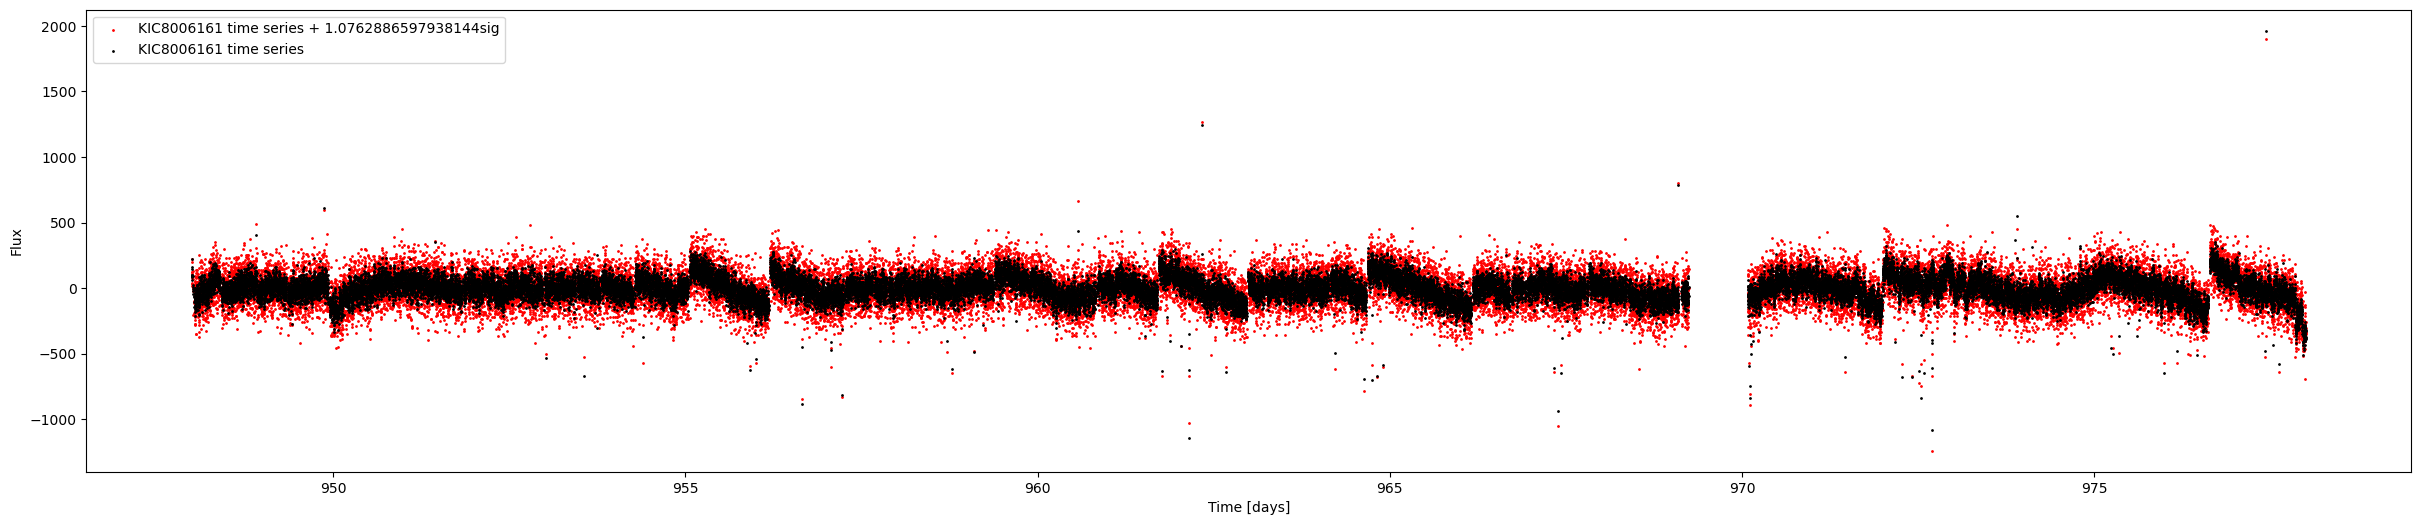

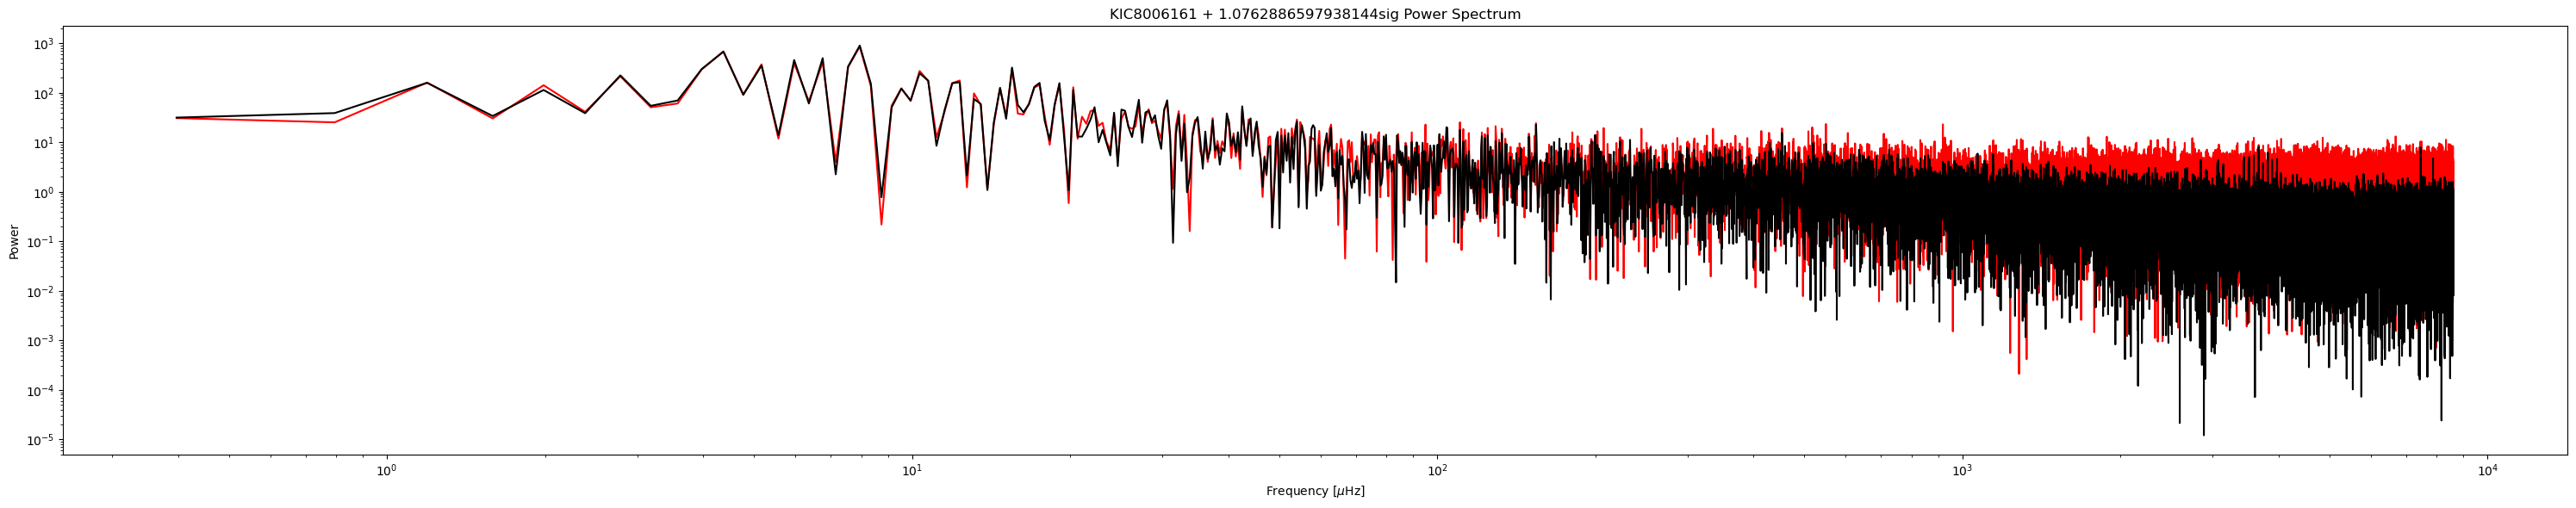

In [51]:
x=x_50

noise_lvls = np.array(noise_lvls)
sig1hrs = (noise_lvls / (2*3600*10**(-6)))**(1/2)
sig_cads = sig1hrs * np.sqrt(3600/delta_t)

flux_noisy1, freq_noisy1, power_noisy1 = make_spectrum_noisy(2, sig_cads[0], times_list[0], fluxes_list[0], labels[0])

fig, ax = plt.subplots(figsize=(30,6))
lc_noise = lk.LightCurve(time=times_list[0], flux=flux_noisy1)
lc_noise.scatter(ax=ax, label=f"{labels[0]} time series + {x}sig", c = "r")
lcs_list[0].scatter(ax=ax, label = f"{labels[0]} time series", c = "k")
ax.set_xlabel("Time [days]")
ax.set_ylabel("Flux")
ax.legend()
plt.show()
    
plt.figure(figsize=(30,6))
plt.plot(freq_noisy1, power_noisy1, c = "r")
plt.plot(freqs_list[0], powers_list[0], c= "k")
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title(f"{labels[0]} + {x}sig Power Spectrum")
plt.yscale("log")
plt.xscale("log")
plt.tight_layout()
plt.show()

In [36]:
#For each x, create noise only histogram and find 99th percentile threshold
#Then create many spectra + x*sig, and find metrics
#Compute mean metric and count the fraction whose metrics > 99th percentile (detection probability, Pdet(x))
#Plot Pdet(x) against x
#Plot mean metric and 99th percentile threshold against (1+x)



In [37]:
#1st step, create function that makes the histogram given x

In [18]:
x_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.2]
thresholds1 = {
    x: threshold_from_x(x, sig_cads[0], freqs_list[0], 99)
    for x in x_values
}

100%|██████████| 500/500 [03:45<00:00,  2.21it/s]


In [19]:
mean_nu_max_metric, detection_prob = detection_probability(1, sig_cads[0], freqs_list[0], 99, 500, times_list[0], fluxes_list[0], labels[0])
print(mean_nu_max_metric, detection_prob)

100%|██████████| 500/500 [00:36<00:00, 13.53it/s]
500it [16:40,  2.00s/it]

3.5132902 0.638


In [20]:
np.save("thresholds1.npy", thresholds1)
#thresholds1 = np.load("thresholds1.npy", allow_pickle = True).item()

In [25]:
mean_nu_max_metrics = []
detection_probs = []
for x in x_values:
    mean_nu_max_metric, detection_prob = detection_probability(x, sig_cads[0], freqs_list[0], 99, 500, times_list[0], fluxes_list[0], labels[0])
    mean_nu_max_metrics.append(mean_nu_max_metric)
    detection_probs.append(detection_prob)

np.save("mean_nu_max_metrics.npy", mean_nu_max_metrics)
np.save("detection_probs.npy", detection_probs)

100%|██████████| 500/500 [00:44<00:00, 11.34it/s]
500it [14:53,  1.79s/it]
100%|██████████| 500/500 [00:42<00:00, 11.64it/s]
500it [13:59,  1.68s/it]
100%|██████████| 500/500 [00:41<00:00, 12.12it/s]
500it [13:31,  1.62s/it]
100%|██████████| 500/500 [00:40<00:00, 12.47it/s]
500it [13:06,  1.57s/it]
100%|██████████| 500/500 [00:41<00:00, 12.17it/s]
500it [13:06,  1.57s/it]
100%|██████████| 500/500 [00:41<00:00, 12.13it/s]
500it [13:09,  1.58s/it]
100%|██████████| 500/500 [00:40<00:00, 12.33it/s]
500it [13:11,  1.58s/it]


In [39]:
mean_nu_max_metrics = np.array(mean_nu_max_metrics)
detection_probs = np.array(detection_probs)

In [40]:
print(mean_nu_max_metrics)
print(detection_probs)

[4.122593  4.1940007 4.2270713 4.2084355 3.972395  3.51748   2.9854527]
[1.    1.    0.998 1.    0.834 0.648 0.26 ]


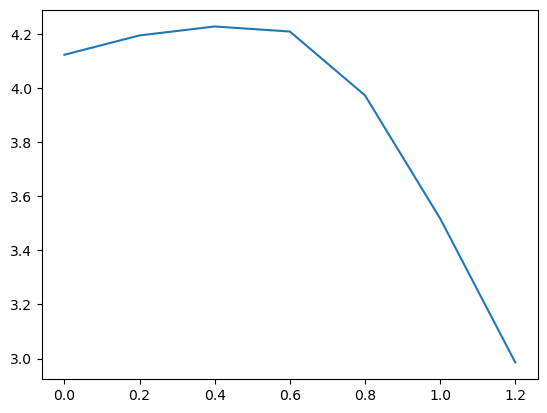

In [41]:
plt.plot(x_values, mean_nu_max_metrics)

In [49]:

x_50 = np.interp(0.5, detection_probs[::-1], x_values[::-1])
print(x_50)

1.0762886597938144


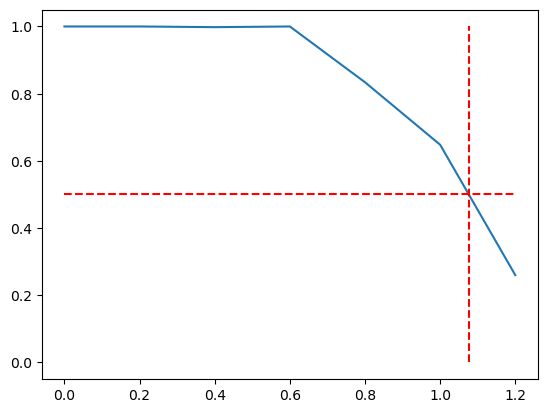

In [48]:
plt.plot(x_values, detection_probs)
plt.hlines(0.5, 0, 1.2, linestyles = "dashed", colors = "red")
plt.vlines(x_50, 0, 1, linestyles = "dashed", colors = "red")

In [50]:
nu_nyq = np.max(freqs_list[0])
delta_t = 10**(6)/(2*nu_nyq)
sig1hr = (1+x_50)*sig_cads[0] / np.sqrt(3600/delta_t)
print(sig1hr)

13.137073811698263
